# KV Cache

### Transformer architecture
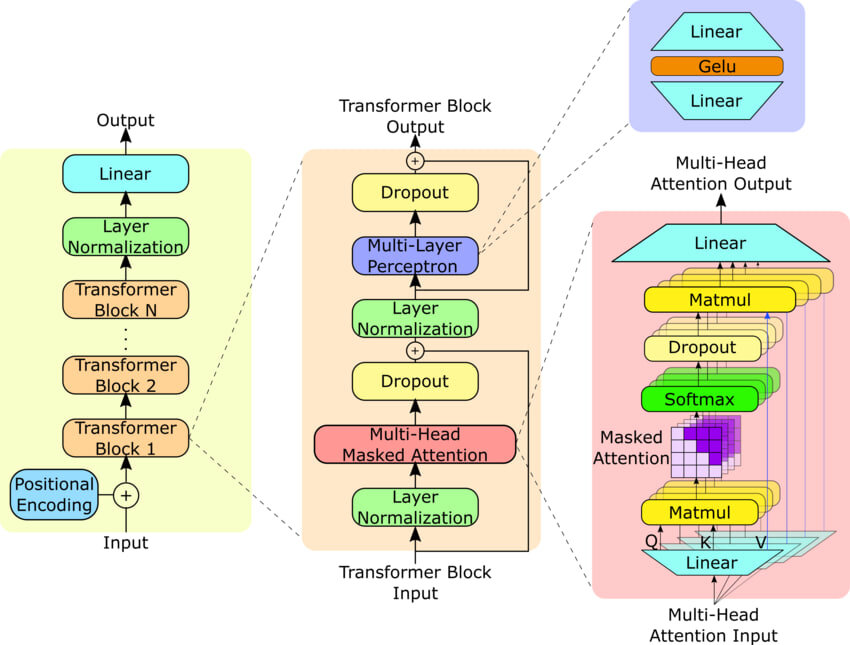

### Attention
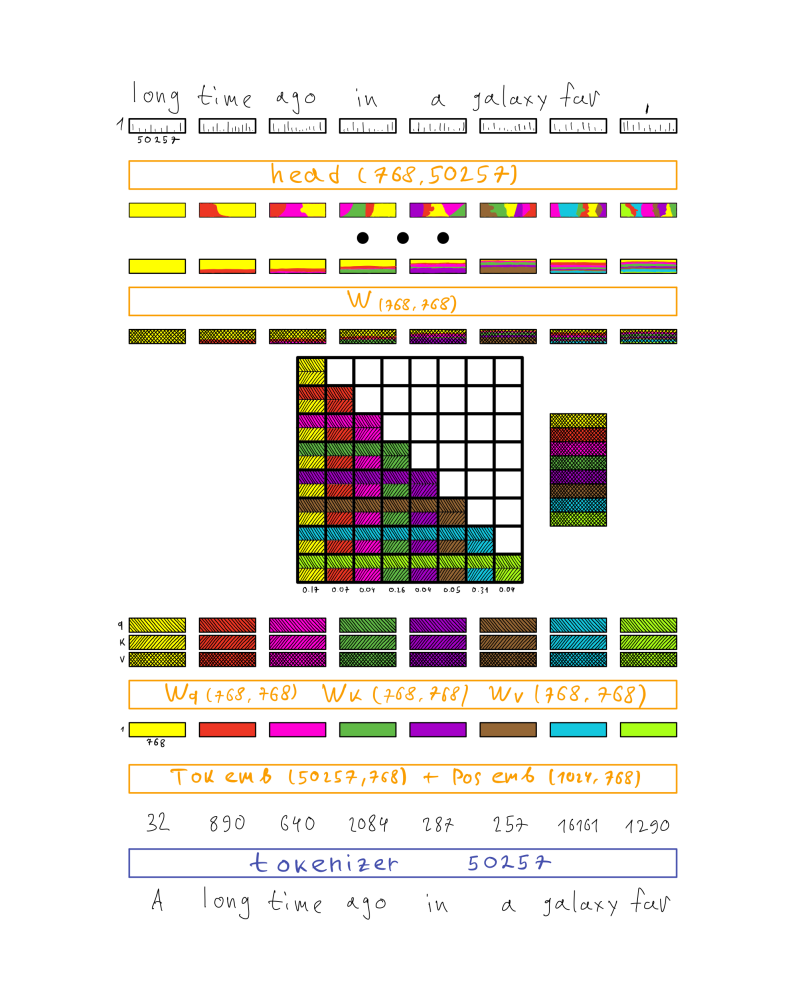

In [ ]:
import time
import tiktoken
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import gc

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1), persistent=False)

        self.register_buffer("cache_k", None, persistent=False)
        self.register_buffer("cache_v", None, persistent=False)

    def forward(self, x, use_cache=False): # NEW
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        values = self.W_value(x)
        queries = self.W_query(x)

        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        if use_cache:
            if self.cache_k is None:
                self.cache_k, self.cache_v = keys, values
            else:
                self.cache_k = torch.cat([self.cache_k, keys], dim=1)
                self.cache_v = torch.cat([self.cache_v, values], dim=1)
            keys, values = self.cache_k, self.cache_v

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        num_tokens_Q = queries.shape[-2]
        num_tokens_K = keys.shape[-2]
        if use_cache:
            mask_bool = self.mask.bool()[
                num_tokens_K - num_tokens_Q:num_tokens_K, :num_tokens_K
            ]
        else:
            mask_bool = self.mask.bool()[:num_tokens_Q, :num_tokens_K]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

    def reset_cache(self):
        self.cache_k, self.cache_v = None, None

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU('tanh'),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = nn.LayerNorm(cfg["emb_dim"])
        self.norm2 = nn.LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x, use_cache=False):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x, use_cache=use_cache) # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = nn.LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx, use_cache=False):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        if use_cache:
            cache_size = 0 if self.trf_blocks[0].att.cache_k is None else self.trf_blocks[0].att.cache_k.shape[1]
            pos_ids = torch.arange(cache_size, cache_size + seq_len, device=in_idx.device, dtype=torch.long)
        else:
            pos_ids = torch.arange(0, seq_len, device=in_idx.device, dtype=torch.long)
        pos_embeds = self.pos_emb(pos_ids)
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        for blk in self.trf_blocks:
            x = blk(x, use_cache=use_cache)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

    def reset_kv_cache(self):
        for blk in self.trf_blocks:
            blk.att.reset_cache()

In [ ]:
def time_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()


def generate_text(
    model,
    idx,
    max_new_tokens,
    context_size=None,
    use_cache=True,
    tokenizer=None,
    print_tokens=False,
):
    model.eval()
    ctx_len = context_size or model.pos_emb.num_embeddings

    per_token_times = []
    with torch.no_grad():
        if use_cache:
            # Initialize cache with full prompt (prefill)
            model.reset_kv_cache()
            logits = model(idx[:, -ctx_len:], use_cache=True)

            for _ in range(max_new_tokens):
                next_idx = logits[:, -1].argmax(dim=-1, keepdim=True)
                idx = torch.cat([idx, next_idx], dim=1)
                if print_tokens and tokenizer is not None:
                    print(tokenizer.decode(next_idx.squeeze(0).tolist()), end="", flush=True)
                t0 = time_sync()
                # feed model only the new token
                logits = model(next_idx, use_cache=True)
                t1 = time_sync()
                per_token_times.append((t1 - t0)*1000)
        else:
            for _ in range(max_new_tokens):
                t0 = time_sync()
                logits = model(idx[:, -ctx_len:], use_cache=False)
                t1 = time_sync()
                per_token_times.append((t1 - t0)*1000)
                next_idx = logits[:, -1].argmax(dim=-1, keepdim=True)
                idx = torch.cat([idx, next_idx], dim=1)
                if print_tokens and tokenizer is not None:
                    print(tokenizer.decode(next_idx.squeeze(0).tolist()), end="", flush=True)

    return idx, per_token_times

def benchmark_generation(model, encoded_tensor, tokenizer, use_cache: bool, label: str, max_new_tokens: int = 800):
    gc.disable()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    model.reset_kv_cache()

    print(f"\n{label}")

    start = time_sync()

    token_ids, per_token_times = generate_text(
        model=model,
        idx=encoded_tensor,
        max_new_tokens=max_new_tokens,
        use_cache=use_cache,
        tokenizer=tokenizer,
        print_tokens=True,
    )
    print()

    total_time = time_sync() - start

    gc.enable()

    return token_ids, per_token_times, total_time

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True        # Query-Key-Value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
# state_dict = torch.load("checkpoints/gpt2_124M.pt", map_location="cpu")
# model.load_state_dict(state_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

start_context = "A long time ago in a galaxy far"

tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded, device=device).unsqueeze(0)

In [ ]:
# without cache
token_ids_no_cache, per_token_times_no_cache, total_time_no_cache = benchmark_generation(
    model, encoded_tensor, tokenizer,
    use_cache=False,
    label="No cache generation (streaming):",
    max_new_tokens = 800
)

print("\nNo cache summary:")
print(f"Time: {total_time_no_cache:.2f} sec")
print(f"{int(len(token_ids_no_cache[0]) / total_time_no_cache)} tokens/sec")

# plot
per_token_times_no_cache_plot = per_token_times_no_cache[1:] #(skip first token as warmup)
plt.figure(figsize=(9, 4.5))
plt.plot(
    range(1, len(per_token_times_no_cache_plot) + 1),
    per_token_times_no_cache_plot,
    label="no cache",
    linewidth=1.5,
)
plt.xlabel("Generated token index")
plt.ylabel("Time per token (ms)")
plt.title("Per-token generation time (no cache)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# with cache
token_ids_cache, per_token_times_cache, total_time_cache = benchmark_generation(
    model, encoded_tensor, tokenizer,
    use_cache=True,
    label="With KV cache generation (streaming):",
    max_new_tokens = 800
)

assert torch.equal(token_ids_no_cache, token_ids_cache)

print("\nWith KV cache summary:")
print(f"Time: {total_time_cache:.2f} sec")
print(f"{int(len(token_ids_cache[0]) / total_time_cache)} tokens/sec")

per_token_times_cache_plot = per_token_times_cache[1:]

plt.figure(figsize=(9, 4.5))
plt.plot(
    range(1, len(per_token_times_no_cache_plot) + 1),
    per_token_times_no_cache_plot,
    label="no cache",
    linewidth=1.5,
)
plt.plot(
    range(1, len(per_token_times_cache_plot) + 1),
    per_token_times_cache_plot,
    label="with KV cache",
    linewidth=1.5,
)
plt.xlabel("Generated token index")
plt.ylabel("Time per token (ms)")
plt.title("Per-token generation time: cache vs no-cache")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Quantization

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import bitsandbytes.functional as bnb_F

MODEL_ID = "Qwen/Qwen2.5-7B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Which weight of q_proj in layer 0 to quantize by hand.
# (row, col) -- change this to inspect different elements.
TARGET = (0, 1)

In [ ]:
# ---------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------
def release_cuda_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


def load_model(precision: str):
    if precision == "bf16":
        return AutoModelForCausalLM.from_pretrained(
            MODEL_ID, dtype=torch.bfloat16, low_cpu_mem_usage=True
        ).to("cuda")

    if precision == "int8":
        cfg = BitsAndBytesConfig(load_in_8bit=True)
        return AutoModelForCausalLM.from_pretrained(
            MODEL_ID, quantization_config=cfg, low_cpu_mem_usage=True
        )

    if precision == "int4":
        cfg = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=False,
        )
        return AutoModelForCausalLM.from_pretrained(
            MODEL_ID, quantization_config=cfg, low_cpu_mem_usage=True
        )

    raise ValueError(f"unknown precision: {precision!r}")


def compute_perplexity(model, text, max_length=1024):
    enc = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=max_length
    ).to(model.device)
    with torch.inference_mode():
        out = model(**enc, labels=enc.input_ids)
    return float(torch.exp(out.loss.float()).item()), int(enc.input_ids.shape[1])


def benchmark(name, model, prompt, max_new_tokens, ppl_text):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Warmup
    with torch.inference_mode():
        model.generate(**inputs, max_new_tokens=4, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.inference_mode():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.eos_token_id
        )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    text = tokenizer.decode(out[0], skip_special_tokens=True)
    mem_gb = model.get_memory_footprint() / 1e9

    ppl, ppl_tokens = compute_perplexity(model, ppl_text)

    metrics = (
        f"[{name}] memory={mem_gb:6.3f} GB  "
        f"latency={elapsed:5.2f}s  "
        f"ppl={ppl:6.3f} (over {ppl_tokens} tokens)"
    )
    output_line = f"[{name}] output: {text}"
    return metrics, output_line

### BF16 reference

In [ ]:
base_model = load_model("bf16")

W_bf16_cpu = base_model.model.layers[0].self_attn.q_proj.weight.data.detach().clone().cpu()
r, c = TARGET
w_orig = W_bf16_cpu[r, c].float().item()

print(f"q_proj weight shape = {tuple(W_bf16_cpu.shape)}")
print(f"target W[{r},{c}] = {w_orig:+.8f}")
print(f"W range          : [{W_bf16_cpu.min()}, {W_bf16_cpu.max()}]")
print(f"W first row range: [{W_bf16_cpu[0].min()}, {W_bf16_cpu[0].max()}]")

del base_model
release_cuda_memory()

### INT8: row-wise absmax quantization (bitsandbytes LLM.int8)

In [ ]:
model_8bit = load_model("int8")
q8 = model_8bit.model.layers[0].self_attn.q_proj

# --- Manual quantization of W[r, c] ---
target_row = W_bf16_cpu[r].float()
scale_manual = target_row.abs().max()
code_manual  = torch.round(torch.tensor(w_orig) / scale_manual * 127).clamp(-127, 127).to(torch.int8)
dequant_manual = code_manual.float() * scale_manual / 127

# --- bitsandbytes' values for the same element ---
W_int8 = q8.weight.data
SCB = q8.weight.SCB

code_bnb = W_int8[r, c].cpu()
scale_bnb = SCB[r].float().cpu()
dequant_bnb = code_bnb.float() * scale_bnb / 127

print(f"original   W[{r},{c}]            = {w_orig:+.8f}")
print()
print(f"row-{r} absmax (manual scale)  = {scale_manual.item():+.8f}")
print(f"SCB[{r}]      (library scale)  = {scale_bnb.item():+.8f}")
print()
print(f"INT8 code (manual)           = {code_manual.item():>4d}")
print(f"INT8 code (bitsandbytes)     = {code_bnb.item():>4d}")
print()
print(f"dequantized (manual)         = {dequant_manual.item():+.8f}")
print(f"dequantized (bitsandbytes)   = {dequant_bnb.item():+.8f}")
print(f"original                     = {w_orig:+.8f}")
print()
print(f"|original - dequant|         = {abs(w_orig - dequant_manual.item()):.2e}")
print(f"INT8 step size for this row  = {(scale_manual / 127).item():.2e}")
print("  (any FP value within +/- step/2 of a code rounds to that code)")

# Save the dequantized value + error for the final summary.
int8_dequant = dequant_manual.item()
err_int8 = abs(w_orig - int8_dequant)

del model_8bit, q8, W_int8, SCB
release_cuda_memory()

### INT4 (NF4): block-wise non-uniform quantization

In [ ]:
model_4bit = load_model("int4")
q4 = model_4bit.model.layers[0].self_attn.q_proj

# The 16 NF4 levels - the entire "alphabet" a 4-bit code can mean.
# Note: NOT evenly spaced.  Densest near 0, sparser in the tails.
NF4_LEVELS = bnb_F.get_4bit_type("nf4", device="cpu")
print("NF4 codebook (16 levels):")
for i, v in enumerate(NF4_LEVELS.tolist()):
    print(f"  code {i:>2d} (binary {i:04b}) -> {v:+.6f}")
print()

# --- Manual quantization of W[r, c] using NF4 ---
# W is flattened in row-major order; figure out which block of 64 the
# target weight falls in, then take that block's absmax as its scale.
BLOCKSIZE = 64
flat = W_bf16_cpu.flatten().float()
flat_idx = r * W_bf16_cpu.shape[1] + c
block_idx = flat_idx // BLOCKSIZE
target_block = flat[block_idx * BLOCKSIZE : (block_idx + 1) * BLOCKSIZE]

block_absmax = target_block.abs().max()
w_normalized = w_orig / block_absmax.item() # in [-1, +1]
code_idx = (NF4_LEVELS - w_normalized).abs().argmin().item()
nf4_value = NF4_LEVELS[code_idx].item()
dequant_manual_nf4 = torch.tensor(nf4_value * block_absmax.item()).to(torch.bfloat16).item()

# --- bitsandbytes' values for the same element ---
# The 4-bit weights are stored packed (two codes per byte) in a 1D tensor,
# and the per-block scales live in q4.weight.quant_state.  Easiest way
# to inspect a single element is to ask the library to dequantize:
W_dequant_4bit = bnb_F.dequantize_4bit(
    q4.weight.data, q4.weight.quant_state
).reshape(W_bf16_cpu.shape)
dequant_bnb_nf4 = W_dequant_4bit[r, c].float().cpu().item()

print(f"original   W[{r},{c}]            = {w_orig:+.8f}")
print(f"block-{block_idx} absmax (scale)       = {block_absmax.item():+.8f}")
print(f"normalized  W[{r},{c}] / scale   = {w_normalized:+.8f}")
print()
print(f"nearest NF4 code             = {code_idx:>2d}  (binary {code_idx:04b})")
print(f"that code represents         = {nf4_value:+.8f}")
print()
print(f"dequantized (manual NF4)     = {dequant_manual_nf4:+.8f}")
print(f"dequantized (bitsandbytes)   = {dequant_bnb_nf4:+.8f}")
print(f"original                     = {w_orig:+.8f}")
print()
print(f"|original - dequant|      = {abs(w_orig - dequant_manual_nf4):.2e}")

err_nf4 = abs(w_orig - dequant_manual_nf4)

print(f"original   W[{r},{c}]            = {w_orig:+.8f}")
print(f"  INT8 dequant               = {int8_dequant:+.8f}   "
      f"err = {err_int8:.2e}")
print(f"  NF4  dequant               = {dequant_manual_nf4:+.8f}   "
      f"err = {err_nf4:.2e}")

del model_4bit, q4, W_dequant_4bit
release_cuda_memory()

INT8 uses 256 evenly-spaced codes (uniform quantization), NF4 uses 16 codes placed at the quantiles of a standard normal (non-uniform quantization)
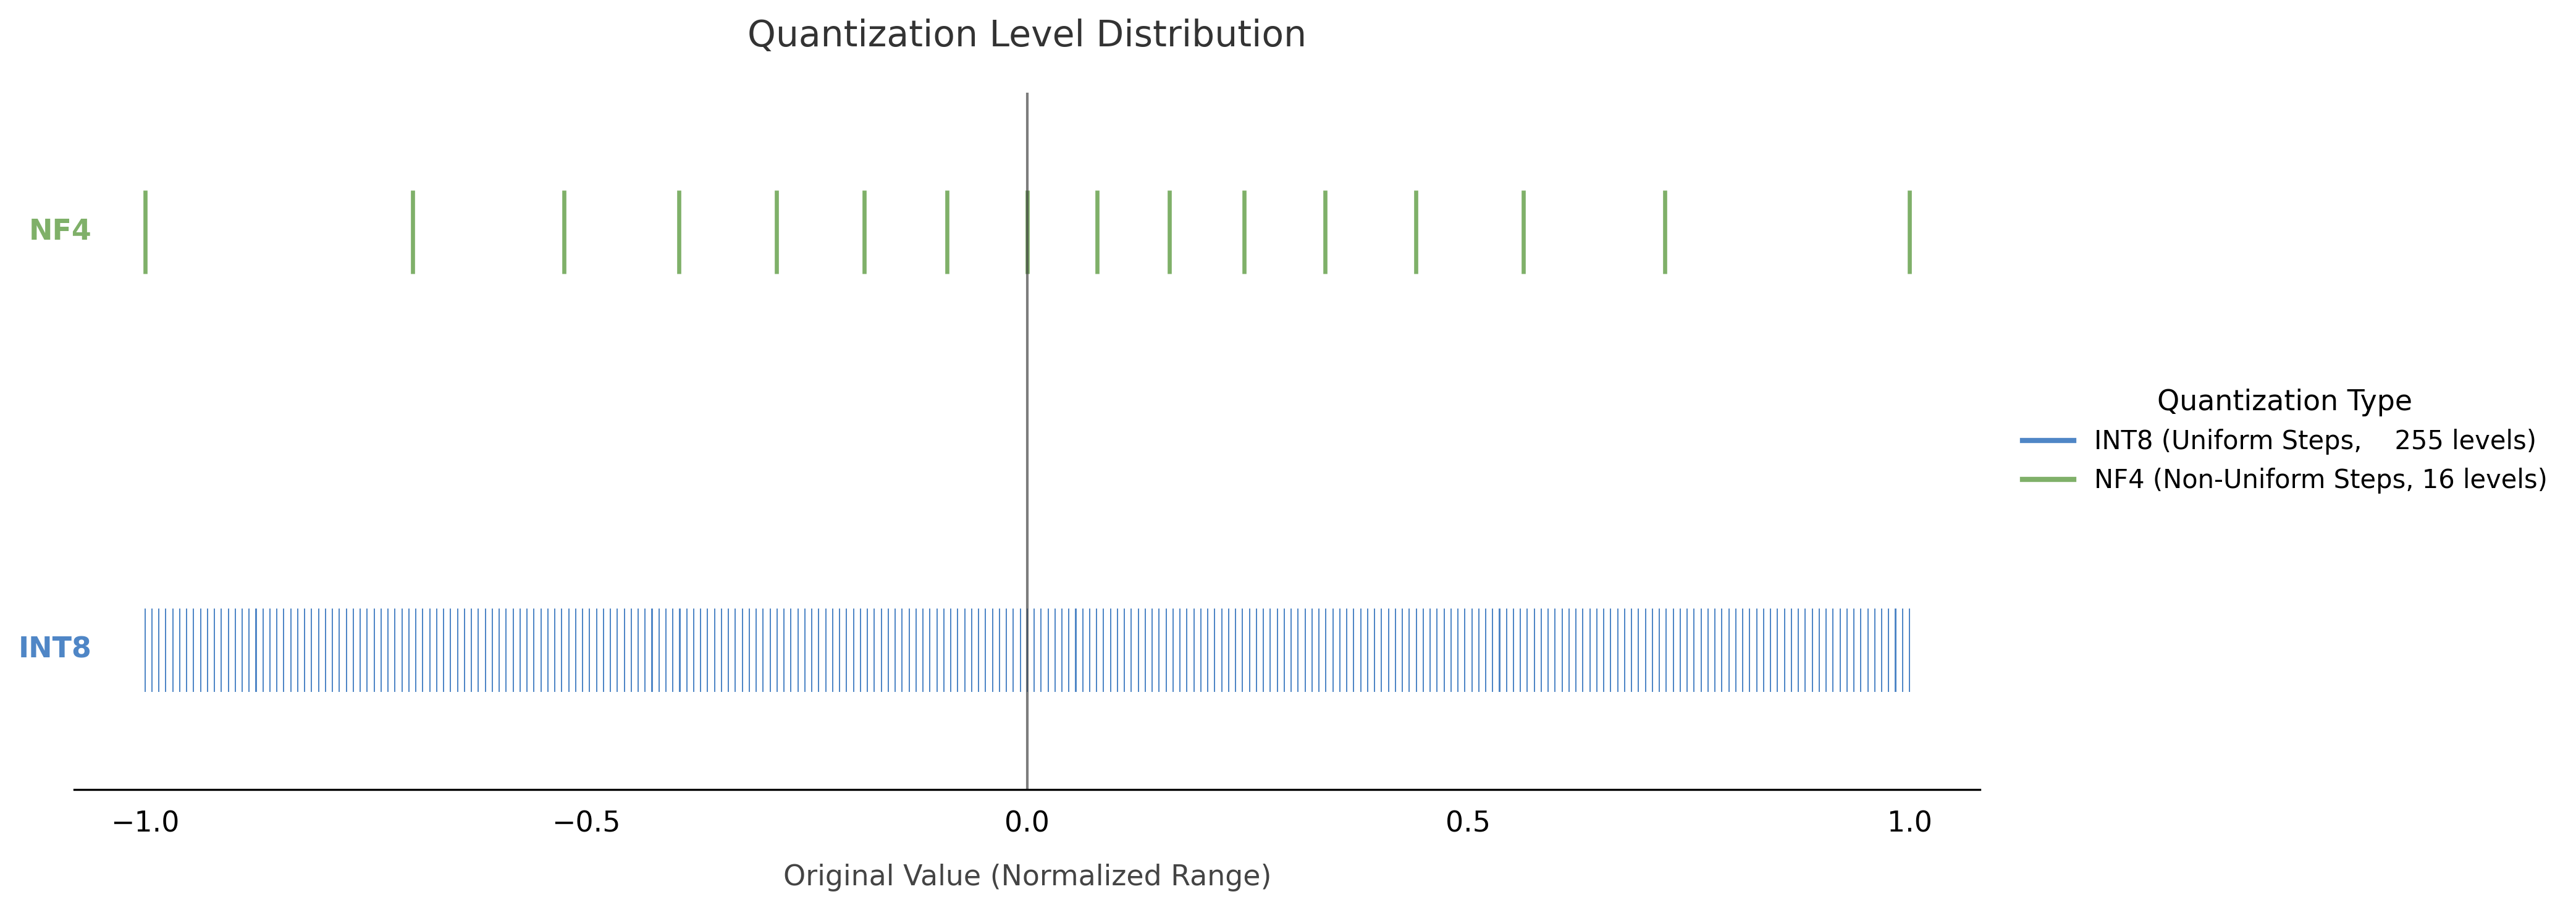

### Side-by-side benchmark: BF16 vs INT8 vs NF4

In [ ]:
PROMPT = "LLM quantization is"
MAX_NEW_TOKENS = 128

PPL_TEXT = (
    "Machine learning is a subfield of artificial intelligence concerned with "
    "the development of algorithms that improve their performance on a task with "
    "experience, without being explicitly programmed for that task. Modern deep "
    "learning, a branch of machine learning based on artificial neural networks "
    "with many layers, has produced state-of-the-art results in computer vision, "
    "natural language processing, speech recognition, and many other domains. "
    "Large language models, in particular, are trained on enormous corpora of "
    "text and learn to predict the next token in a sequence. The performance of "
    "such models on language modelling is often measured by perplexity, which "
    "quantifies how surprised the model is by a held-out sample of text. Formally, "
    "perplexity is the exponential of the average negative log-likelihood per "
    "token: a lower value means the model assigns higher probability to the "
    "observed sequence, and is therefore a better predictor of natural language. "
    "Quantization is a technique for reducing the memory and compute cost of "
    "running large neural networks by representing their weights with fewer bits "
    "than the standard sixteen- or thirty-two-bit floating-point formats. The "
    "central challenge in quantization is to compress the model without "
    "significantly degrading its predictive quality. Empirically, modern "
    "quantization schemes such as eight-bit integer quantization and four-bit "
    "normal-float quantization preserve nearly all of the original model's "
    "perplexity while reducing the memory footprint by factors of two to four. "
    "This makes quantization indispensable for deploying large language models "
    "on consumer hardware or in latency-sensitive serving environments where "
    "memory bandwidth is the dominant bottleneck. The trade-off between bits "
    "per weight, raw inference throughput, and downstream accuracy is one of "
    "the central practical questions in modern model deployment, and the answer "
    "depends sensitively on the underlying GPU architecture as well as on the "
    "specific quantization algorithm chosen for the workload."
)

metric_lines = []
output_lines = []
for precision in ("bf16", "int8", "int4"):
    model = load_model(precision)
    metrics, output = benchmark(precision, model, PROMPT, MAX_NEW_TOKENS, PPL_TEXT)
    metric_lines.append(metrics)
    output_lines.append(output)
    del model
    release_cuda_memory()

print()
for line in metric_lines:
    print(line)
print()
for line in output_lines:
    print(line)
    print()